# Heart Disease Prediction

Author: Jiaen Qi

Course Project, UC Irvine, June 3, Spring 2026

## Introduction

- In this project, the goal is to predict whether a patient has heart disease based on health information like age, cholesterol, blood pressure, maximum heart rate, etc. 
- We will use different models to make predictions, and compare which one works best for our case. 

## Setup

In [1]:
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

## Read the Data

In [2]:
df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")

df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


- This dataset has one row for each patient. The column `target` is what I want to predict. 
- `0` means no heart disease and `1` means heart disease. 
- The other columns are health measurements

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [4]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [5]:
df.isna().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

In [6]:
(df[["cholesterol", "resting bp s", "max heart rate"]] == 0).sum()

cholesterol       172
resting bp s        1
max heart rate      0
dtype: int64

- I checked for missing values and also checked if some medical measurements were recorded as `0`.
- A cholesterol value of `0` is not medically realistic, so I treat these values as missing. For model training, I replace them with the median cholesterol value calculated from the training set. 

## Simple Analysis

In [7]:
# See some average values by heart disease status

df_valid_chol = df[df["cholesterol"] > 0]

df_valid_chol.groupby("target")[
    ["age", "cholesterol", "resting bp s", "max heart rate"]
].mean()

,age,cholesterol,resting bp s,max heart rate
target,,,,
0,50.872458,240.221811,129.767098,151.650647
1,56.041929,252.354298,135.752621,132.614256


In [8]:
# Count how many people have disease or no disease

df["target"].value_counts()

target
1    629
0    561
Name: count, dtype: int64

## Visualize the Data

In [9]:
df["heart_disease"] = df["target"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})


# Chart 1: Age distribution

alt.Chart(df).mark_bar().encode(
    x = alt.X("age:Q",title="Age"),
    y = alt.Y("count()", title="Number of Patients"),
    color = "heart_disease:N"
)

alt.Chart(...)

In [10]:
# Chart 2: Age vs Max Heart Rate

alt.Chart(df).mark_circle(size=60).encode(
    x = "age",
    y = "max heart rate",
    color = "heart_disease",
    tooltip = ["age","max heart rate","heart_disease"]
)

alt.Chart(...)

- If we use alt.Chart(df).mark_circle().encode() to generate one single plot with both heart disease and no heart disease together, it will look like a mess. They would mix up together. So I decide to make two separate charts and compare. 

In [11]:
c1 = alt.Chart(df[df["heart_disease"] == "Heart Disease"]).mark_circle(size=60).encode(
    x = alt.X("age:Q",title="Age",scale=alt.Scale(zero=False)),
    y = alt.Y("max heart rate:Q", title="Maximum Heart Rate"),
    color = alt.Color("max heart rate:Q", scale=alt.Scale(scheme="oranges")),
    tooltip=["age", "max heart rate", "heart_disease"]
)

c2 = alt.Chart(df[df["heart_disease"] == "No Heart Disease"]).mark_circle(size=60).encode(
    x=alt.X("age:Q", title="Age",scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate"),
    color = alt.Color("max heart rate:Q", scale=alt.Scale(scheme="oranges")),
    tooltip=["age", "max heart rate", "heart_disease"]
)

c1|c2

alt.HConcatChart(...)

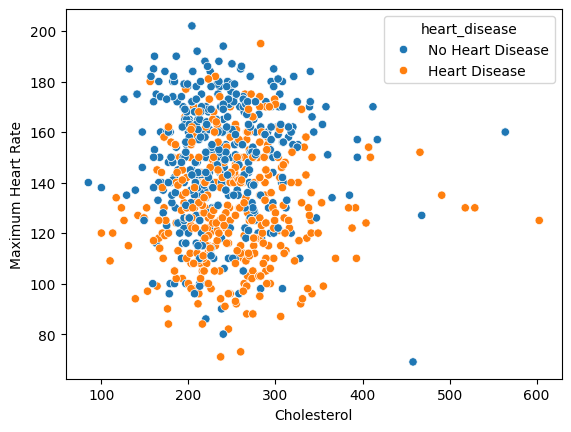

In [12]:
# Chart 3: Cholesterol vs Maximum Heart Rate

sns.scatterplot(
    data = df[df["cholesterol"] > 0],
    x = "cholesterol",
    y = "max heart rate",
    hue = "heart_disease"
)

plt.xlabel("Cholesterol")
plt.ylabel("Maximum Heart Rate")
plt.show()

## Prepare the data

In [13]:
cols = [
    "age",
    "sex",
    "chest pain type",
    "resting bp s",
    "cholesterol",
    "fasting blood sugar",
    "resting ecg",
    "max heart rate",
    "exercise angina",
    "oldpeak",
    "ST slope"
]

# Prepare features and target
X = df[cols].copy()
y = df["target"]

# Treat cholesterol = 0， resting bp s = 0 as missing
X["cholesterol"] = X["cholesterol"].replace(0, np.nan)
X["resting bp s"] = X["resting bp s"].replace(0, np.nan)

# Split the data
X_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026
)

# Use the training-set median to fill missing cholesterol values
cholesterol_median = X_train["cholesterol"].median()
bp_median = X_train["resting bp s"].median()

X_train["cholesterol"] = X_train["cholesterol"].fillna(cholesterol_median)
x_test["cholesterol"] = x_test["cholesterol"].fillna(cholesterol_median)


X_train["resting bp s"] = X_train["resting bp s"].fillna(bp_median)
x_test["resting bp s"] = x_test["resting bp s"].fillna(bp_median)

print("Training-set cholesterol median:", cholesterol_median)
print("Training-set resting BP median:", bp_median)

Training-set cholesterol median: 239.0
Training-set resting BP median: 130.0


- This is a classfication problem, not a regression problem. 
- Since the model is predicting a category (heart disease or no heart disease), the target is not a continuous number. 

## Predict the data

## Logistic Regression

In [14]:
clf = LogisticRegression(max_iter=5000)
clf.fit(X_train,y_train)
clf_pred = clf.predict(x_test)

accuracy_score(y_test,clf_pred)

0.8277310924369747

- Here I use LogisticRegression to predict the heart disease. The model tried to find the best coefficients, but it stopped because the default number of iterations was not enough (what the notebook has shown). So I use `max_iter` to fix. See the reference at the bottom. It does not change the dataset, but only gives the process more time to find a stable model. 
- The logistic regression model has about `82.77%` accuracy on the test set. This means the model correctly predicted whether a patient had heart disease for about 83% of the test patients. 

## Decision Tree Model

- Next, we use the `decision tree` to compare with logistic regression and show a different machine learning method. Logistic regression and decision tree both do classification, but they work differently. Then let's see which one is better. 

- Since we have prepared the data above, we will directly use the training data to fit the model, and then predict

In [15]:
clf2 = DecisionTreeClassifier(max_depth=4,random_state=2026)
clf2.fit(X_train,y_train)
clf2_pred = clf2.predict(x_test)

accuracy_score(y_test,clf2_pred)

0.7899159663865546

- Now we get the accuracy of the decision tree model `78.99%` , which is slightly lower than logistic regression. This suggests that, for this train-test-split, logistic regression has a better performance. 

## Random Forest Model

- Also, we have learned the `RandomForestClassifier` in class. It is a model which builds many decision trees and combines their predictions. We want to see if this model could be more stable and have a more accurate prediction.

In [16]:
clf3 = RandomForestClassifier(
    n_estimators=100,
    random_state=2026
)

clf3.fit(X_train, y_train)

clf3_pred = clf3.predict(x_test)

accuracy_score(y_test, clf3_pred)

0.9411764705882353

- The random forest model achieves about `94.12%` accuracy, which is higher than both logistic regression and the single decision tree. This suggests that combining many decision trees indeed helps the model make more accurate and stable predictions here. 

In [17]:
print(classification_report(y_test, clf3_pred))

cm = confusion_matrix(y_test, clf3_pred)
cm

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       112
           1       0.94      0.94      0.94       126

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.94      0.94       238



array([[105,   7],
       [  7, 119]])

Since `0` is No Heart Disease and `1` is Heart Disease, the four values mean: 

- 105: Patients who did not have heart disease and were correctly predicted as having no heart disease.
- 7: Patients who did not have heart disease but were incorrectly predicted as having heart disease.
- 7: Patients who had heart disease but were incorrectly predicted as having no heart disease.
- 119: Patients who had heart disease and were correctly predicted as having heart disease.

Therefore, the model correctly identified 119 out of 126 patients with heart disease, while only 7 patients with heart disease were missed. It also correctly identified 105 out of 112 patients without heart disease.

## K-Nearest Neighbors

In [18]:
clf4 = KNeighborsClassifier(n_neighbors=5)

clf4.fit(X_train, y_train)

clf4_pred = clf4.predict(x_test)

accuracy_score(y_test, clf4_pred)

0.6428571428571429

In [19]:
clf4_scaled = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

clf4_scaled.fit(X_train, y_train)
clf4_scaled_pred = clf4_scaled.predict(x_test)

accuracy_score(y_test, clf4_scaled_pred)

0.8361344537815126

- I also tried KNN with scaling. This matters because KNN uses distances, and columns like cholesterol and oldpeak are on very different scales. Scaling makes the columns more comparable before KNN calculates distances. 
- We can see the difference between two accuracy score here. The first one is without scaling which got `64.29%` accuracy, while the second one is with scaling which got `83.61%` accuracy. 
- However, even with scaling, the KNN model is still not as good as the Random Forest. 

## Compare different predictions

In [20]:
test_df = x_test.copy()

test_df["actual"] = y_test

test_df["logistic_pred"] = clf.predict(x_test)
test_df["tree_pred"] = clf2.predict(x_test)
test_df["forest_pred"] = clf3.predict(x_test)
test_df["KNN_pred"] = clf4_scaled.predict(x_test)

c0 = alt.Chart(test_df).mark_circle(size=70).encode(
    x=alt.X("age:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate", scale=alt.Scale(zero=False)),
    color=alt.Color(
        "actual:N",
        title="Actual",
        scale=alt.Scale(domain=[0, 1], range=["green", "red"])
    ),
    tooltip=["age", "max heart rate", "actual"]
).properties(
    title="Original Data",
    width=300,
    height=280
)

c1 = alt.Chart(test_df).mark_circle(size=70).encode(
    x=alt.X("age:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate", scale=alt.Scale(zero=False)),
    color=alt.Color(
        "logistic_pred:N",
        title="Logistic Prediction",
        scale=alt.Scale(domain=[0, 1], range=["blue", "orange"])
    ),
    tooltip=["age", "max heart rate", "logistic_pred"]
).properties(
    title="Logistic Regression",
    width=300,
    height=280
)

c2 = alt.Chart(test_df).mark_circle(size=70).encode(
    x=alt.X("age:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate", scale=alt.Scale(zero=False)),
    color=alt.Color(
        "tree_pred:N",
        title="Decision Tree Prediction",
        scale=alt.Scale(domain=[0, 1], range=["blue", "orange"])
    ),
    tooltip=["age", "max heart rate", "tree_pred"]
).properties(
    title="Decision Tree",
    width=300,
    height=280
)

c3 = alt.Chart(test_df).mark_circle(size=70).encode(
    x=alt.X("age:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate", scale=alt.Scale(zero=False)),
    color=alt.Color(
        "forest_pred:N",
        title="Random Forest Prediction",
        scale=alt.Scale(domain=[0, 1], range=["blue", "orange"])
    ),
    tooltip=["age", "max heart rate", "forest_pred"]
).properties(
    title="Random Forest",
    width=300,
    height=280
)

c4 = alt.Chart(test_df).mark_circle(size=70).encode(
    x=alt.X("age:Q", title="Age", scale=alt.Scale(zero=False)),
    y=alt.Y("max heart rate:Q", title="Maximum Heart Rate", scale=alt.Scale(zero=False)),
    color=alt.Color(
        "KNN_pred:N",
        title="KNN Prediction",
        scale=alt.Scale(domain=[0, 1], range=["blue", "orange"])
    ),
    tooltip=["age", "max heart rate", "KNN_pred"]
).properties(
    title="KNN",
    width=300,
    height=280
)

c0 & (c1 | c2) & (c3 | c4)

alt.VConcatChart(...)

- The random forest model has the highest test accuracy, so I would choose it as the best model. The prediction chart also looks the closest to the actual chart than the other models, but the accuracy score is the main reason I choose it. The graph is just for a better visualization. 
- Therefore, the Random Forest performs the best, both visually and numerically

## 5-fold Cross-Validation

Since a single train-test split may give a result that depends too much on one particular split. 
Five-fold cross-validation evaluates the model across multiple data splits, giving a more reliable estimate of its general performance.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=2026),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=2026),
    "KNN with Scaling": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    )
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(name)
    print("Fold accuracies:", np.round(scores, 4))
    print("Mean accuracy:", round(scores.mean(), 4))
    print()

Logistic Regression
Fold accuracies: [0.8639 0.7958 0.9053 0.7895 0.8053]
Mean accuracy: 0.8319

Decision Tree
Fold accuracies: [0.7696 0.822  0.8579 0.7842 0.8316]
Mean accuracy: 0.8131

Random Forest
Fold accuracies: [0.8901 0.8901 0.9053 0.9211 0.9105]
Mean accuracy: 0.9034

KNN with Scaling
Fold accuracies: [0.8743 0.8063 0.8789 0.8421 0.8579]
Mean accuracy: 0.8519



The training data is divided into five parts, and each model is trained and evaluated five times using different validation folds.

The mean cross-validation accuracies are:

- Logistic Regression: 83.19%
- Decision Tree: 81.31%
- Random Forest: 90.34%
- KNN with Scaling: 85.19%

Random Forest achieves the highest mean accuracy at 90.34%. Its accuracy also remains relatively consistent across the five folds, ranging from about 89% to 92%.

This suggests that Random Forest performs well across different data splits and is the strongest model among the four models tested.

## Summary

Overall, I used the Heart Disease dataset to predict whether a patient has heart disease. Since the target variable is either 0 or 1, this is a binary classification problem.

I first explored and cleaned the dataset using Pandas. I identified unrealistic values such as cholesterol and resting blood pressure recorded as 0, treated them as missing values, and replaced them using median values calculated from the training set. I also used visualizations to examine relationships between patient characteristics and heart disease status.

I compared Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and scaled KNN. Random Forest achieved the highest test accuracy at `94.12%`. Feature standardization also improved KNN accuracy from `64.29%` to `83.61%`, showing the importance of scaling for distance-based models.

I further evaluated the Random Forest model using precision, recall, F1-score, a confusion matrix, and 5-fold cross-validation. The model achieved approximately `0.94 precision`, recall, and F1-score, and its mean cross-validation accuracy was `90.34%`, the highest among the models tested. These results suggest that Random Forest performed well and remained relatively stable across different data splits.

This project demonstrates how machine learning can be applied to health-related classification problems. However, the model was trained on a single dataset and we should be cautious about generalizing the results to other populations.

## References

- Heart Disease Dataset — Kaggle
  https://www.kaggle.com/datasets/mexwell/heart-disease-dataset/code

- Scikit-learn preprocessing
  https://scikit-learn.org/stable/modules/preprocessing.html

- Scikit-learn KNN
  https://scikit-learn.org/stable/modules/neighbors.html

- StandardScaler
  https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=036f13a2-8c99-4638-a2c8-7b9ebb790039' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>